# RAFT Fine-Tuning Llama 3.1 8B — Unsloth + LoRA (Dataset v5, Notebook v6)

Notebook ini memperbaiki training dan evaluasi RAFT v5.

Perubahan utama:

- memakai split train, validation, dan test yang sudah tetap;
- memakai `selected_doc_ids` dan `rejected_doc_ids` sebagai ground truth;
- memakai prompt–completion dengan completion-only loss;
- menyeimbangkan kelas `none` dan `partial` secara opsional hanya pada train;
- memakai evaluasi context selection, abstention, format lengkap, dan answer token F1;
- memperbaiki metrik untuk kasus selected context kosong;
- menyimpan hash dataset, versi library, konfigurasi generation, dan plot;
- test set tidak dijalankan secara default;
- merged model dimuat ulang dan dapat diverifikasi setelah proses save.

> Catatan: oversampling bukan pengganti penambahan contoh no-answer dan partial yang lebih beragam. Untuk eksperimen final, tambahkan data baru daripada hanya menduplikasi contoh lama.


## 0. Instalasi

Jalankan hanya bila lingkungan belum memiliki versi Unsloth dan TRL yang sesuai, lalu restart kernel.

In [1]:
# Jalankan bila diperlukan:
# !pip install -U unsloth unsloth_zoo trl transformers datasets peft accelerate bitsandbytes tensorboard

## 1. Import dan pemeriksaan lingkungan

In [2]:
# Unsloth harus diimpor sebelum torch/transformers agar patch optimisasi diterapkan.
from unsloth import FastLanguageModel, is_bfloat16_supported

import gc
import hashlib
import importlib.metadata
import inspect
import json
import os
import platform
import random
import re
from collections import Counter
from datetime import datetime
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import transformers
import trl

from datasets import Dataset, concatenate_datasets, load_dataset
from packaging import version
from transformers import (
    EarlyStoppingCallback,
    GenerationConfig,
)

SEED = 3407

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print("=" * 72)
print("ENVIRONMENT")
print("=" * 72)
print(f"Python      : {platform.python_version()}")
print(f"PyTorch     : {torch.__version__}")
print(f"Transformers: {transformers.__version__}")
print(f"TRL         : {trl.__version__}")
print(f"CUDA        : {torch.cuda.is_available()}")

assert torch.cuda.is_available(), "CUDA tidak tersedia."
assert version.parse(trl.__version__) >= version.parse("0.24.0"), (
    "Notebook ini membutuhkan TRL >= 0.24.0 agar prompt-completion dan "
    "completion_only_loss tersedia."
)

for gpu_index in range(torch.cuda.device_count()):
    properties = torch.cuda.get_device_properties(gpu_index)
    print(
        f"GPU {gpu_index}: {torch.cuda.get_device_name(gpu_index)} | "
        f"{properties.total_memory / 1024**3:.2f} GB | "
        f"compute {properties.major}.{properties.minor}"
    )
print("=" * 72)


🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.


/workspace/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


🦥 Unsloth Zoo will now patch everything to make training faster!
ENVIRONMENT
Python      : 3.10.12
PyTorch     : 2.11.0+cu128
Transformers: 5.5.0
TRL         : 0.24.0
CUDA        : True
GPU 0: NVIDIA B200 | 178.36 GB | compute 10.0


## 2. Konfigurasi eksperimen

In [3]:
# -----------------------------
# Model
# -----------------------------
MODEL_NAME = "../model/Meta-Llama-3.1-8B-Instruct"
MAX_SEQ_LENGTH = 4096
DTYPE = None

# False = LoRA 16-bit/bfloat16, cocok untuk GPU besar seperti B200.
# True  = QLoRA 4-bit, gunakan bila VRAM terbatas.
LOAD_IN_4BIT = False

# -----------------------------
# Dataset v5
# -----------------------------
TRAIN_DATASET_PATH = "../data/dataset/split/raft_dataset_finalv5_train.jsonl"
VALIDATION_DATASET_PATH = "../data/dataset/split/raft_dataset_finalv5_validation.jsonl"
TEST_DATASET_PATH = "../data/dataset/split/raft_dataset_finalv5_test.jsonl"

# -----------------------------
# Penyeimbangan train
# -----------------------------
# Ini hanya diterapkan pada train. Validation dan test tidak diubah.
ENABLE_ANSWERABILITY_OVERSAMPLING = True
NONE_REPEAT = 5       # 11 none -> 55 kemunculan
PARTIAL_REPEAT = 2    # 11 partial -> 22 kemunculan

# -----------------------------
# Kontrol evaluasi
# -----------------------------
# Test v5 sebelumnya sudah pernah dilihat. Biarkan False selama iterasi.
# Untuk klaim final, gunakan holdout baru yang belum pernah dilihat.
RUN_TEST = False
VERIFY_MERGED_MODEL = True

# -----------------------------
# Output eksperimen
# -----------------------------
RUN_ID = (
    "raft_v6_none5_partial2_seed3407_"
    + datetime.now().strftime("%Y%m%d_%H%M%S")
)
OUTPUT_DIR = f"../model/runs/{RUN_ID}"
ADAPTER_DIR = f"/workspace/model/{RUN_ID}_adapter"
MERGED_DIR = f"/workspace/model/{RUN_ID}_merged"

# Isi dengan path checkpoint untuk melanjutkan training.
RESUME_FROM_CHECKPOINT = None

for dataset_path in [
    TRAIN_DATASET_PATH,
    VALIDATION_DATASET_PATH,
    TEST_DATASET_PATH,
]:
    assert Path(dataset_path).exists(), f"File tidak ditemukan: {dataset_path}"

Path(OUTPUT_DIR).mkdir(parents=True, exist_ok=False)

print("RUN_ID     :", RUN_ID)
print("OUTPUT_DIR :", OUTPUT_DIR)
print("Konfigurasi siap.")


RUN_ID     : raft_v6_none5_partial2_seed3407_20260717_002824
OUTPUT_DIR : ../model/runs/raft_v6_none5_partial2_seed3407_20260717_002824
Konfigurasi siap.


## 3. Memuat base model

In [4]:
model, tokenizer = FastLanguageModel.from_pretrained(
    model_name=MODEL_NAME,
    max_seq_length=MAX_SEQ_LENGTH,
    dtype=DTYPE,
    load_in_4bit=LOAD_IN_4BIT,
)

assert tokenizer.chat_template, (
    "Tokenizer tidak mempunyai chat_template. "
    "Pastikan tokenizer berasal dari Meta-Llama-3.1-8B-Instruct."
)

if tokenizer.pad_token_id is None:
    tokenizer.pad_token = tokenizer.eos_token

tokenizer.padding_side = "right"

chat_template_text = str(tokenizer.chat_template)
if "Today Date:" in chat_template_text:
    print(
        "PERINGATAN: chat template menyisipkan tanggal statis. "
        "Training tetap konsisten selama template train dan inference sama."
    )

print("Model dan tokenizer berhasil dimuat.")
print("EOS token:", tokenizer.eos_token)
print("PAD token:", tokenizer.pad_token)


==((====))==  Unsloth 2026.6.9: Fast Llama patching. Transformers: 5.5.0.
   \\   /|    NVIDIA B200. Num GPUs = 1. Max memory: 178.361 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.11.0+cu128. CUDA: 10.0. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = TRUE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights: 100%|██████████| 291/291 [00:07<00:00, 37.72it/s]
Unsloth: Will load ../model/Meta-Llama-3.1-8B-Instruct as a legacy tokenizer.


../model/Meta-Llama-3.1-8B-Instruct does not have a padding token! Will use pad_token = <|finetune_right_pad_id|>.
PERINGATAN: chat template menyisipkan tanggal statis. Training tetap konsisten selama template train dan inference sama.
Model dan tokenizer berhasil dimuat.
EOS token: <|eot_id|>
PAD token: <|finetune_right_pad_id|>


## 4. Memasang LoRA

In [5]:
model = FastLanguageModel.get_peft_model(
    model,
    r=16,
    target_modules=[
        "q_proj",
        "k_proj",
        "v_proj",
        "o_proj",
        "gate_proj",
        "up_proj",
        "down_proj",
    ],
    lora_alpha=32,
    lora_dropout=0.0,
    bias="none",
    use_gradient_checkpointing="unsloth",
    random_state=SEED,
    use_rslora=False,
    loftq_config=None,
)

if hasattr(model, "print_trainable_parameters"):
    model.print_trainable_parameters()

print("LoRA berhasil dipasang.")

Unsloth 2026.6.9 patched 32 layers with 32 QKV layers, 32 O layers and 32 MLP layers.


trainable params: 41,943,040 || all params: 8,072,204,288 || trainable%: 0.5196
LoRA berhasil dipasang.


## 5. Memuat split dataset v5

In [6]:
train_base_raw = load_dataset(
    "json",
    data_files=TRAIN_DATASET_PATH,
    split="train",
)
validation_raw = load_dataset(
    "json",
    data_files=VALIDATION_DATASET_PATH,
    split="train",
)
test_raw = load_dataset(
    "json",
    data_files=TEST_DATASET_PATH,
    split="train",
)

# Sebelum oversampling, train_raw menunjuk data asli.
train_raw = train_base_raw

print("Train asli :", len(train_base_raw))
print("Validation :", len(validation_raw))
print("Test       :", len(test_raw))
print(
    "Distribusi train asli:",
    Counter(train_base_raw["answerability"]),
)


Train asli : 269
Validation : 34
Test       : 33
Distribusi train asli: Counter({'full': 247, 'none': 11, 'partial': 11})


## 6. Validasi struktur dan kebocoran data

In [7]:
REQUIRED_COLUMNS = {
    "instruction",
    "documents",
    "completion",
    "record_id",
    "selected_doc_ids",
    "rejected_doc_ids",
    "answerability",
    "document_judgments",
    "quality_status",
    "split",
}


def normalize_document(text):
    return re.sub(r"\s+", " ", text.strip().lower())


def document_hash(text):
    return hashlib.sha256(
        normalize_document(text).encode("utf-8")
    ).hexdigest()


def validate_record(record, expected_split):
    missing = REQUIRED_COLUMNS - set(record)
    assert not missing, (
        f"{record.get('record_id', '?')}: field hilang {sorted(missing)}"
    )

    assert record["quality_status"] == "approved", (
        f"{record['record_id']}: quality_status bukan approved"
    )
    assert record["split"] == expected_split, (
        f"{record['record_id']}: split={record['split']}, "
        f"seharusnya {expected_split}"
    )

    document_count = len(record["documents"])
    selected = list(record["selected_doc_ids"])
    rejected = list(record["rejected_doc_ids"])

    assert sorted(selected + rejected) == list(
        range(1, document_count + 1)
    ), f"{record['record_id']}: label bukan partisi lengkap"

    assert not (set(selected) & set(rejected)), (
        f"{record['record_id']}: selected/rejected bertumpang tindih"
    )

    if record["answerability"] == "none":
        assert selected == [], (
            f"{record['record_id']}: none tetapi selected tidak kosong"
        )
    else:
        assert selected, (
            f"{record['record_id']}: answerable tetapi selected kosong"
        )

    assert record["answerability"] in {"full", "partial", "none"}, (
        f"{record['record_id']}: answerability tidak valid"
    )
    assert str(record["completion"]).strip(), (
        f"{record['record_id']}: completion kosong"
    )

    judgments = record["document_judgments"]
    assert len(judgments) == document_count, (
        f"{record['record_id']}: jumlah judgment tidak sama dengan dokumen"
    )

    judgment_ids = [int(item["document"]) for item in judgments]
    assert sorted(judgment_ids) == list(range(1, document_count + 1)), (
        f"{record['record_id']}: ID judgment tidak lengkap/duplikat"
    )

    selected_from_judgment = sorted(
        int(item["document"])
        for item in judgments
        if str(item["label"]).lower() == "selected"
    )
    rejected_from_judgment = sorted(
        int(item["document"])
        for item in judgments
        if str(item["label"]).lower() == "rejected"
    )

    assert selected_from_judgment == sorted(selected), (
        f"{record['record_id']}: judgment selected tidak cocok"
    )
    assert rejected_from_judgment == sorted(rejected), (
        f"{record['record_id']}: judgment rejected tidak cocok"
    )


for split_name, dataset in [
    ("train", train_base_raw),
    ("validation", validation_raw),
    ("test", test_raw),
]:
    for record in dataset:
        validate_record(record, split_name)

record_id_sets = {
    "train": set(train_base_raw["record_id"]),
    "validation": set(validation_raw["record_id"]),
    "test": set(test_raw["record_id"]),
}

assert not (
    record_id_sets["train"] & record_id_sets["validation"]
), "Record train dan validation overlap."
assert not (
    record_id_sets["train"] & record_id_sets["test"]
), "Record train dan test overlap."
assert not (
    record_id_sets["validation"] & record_id_sets["test"]
), "Record validation dan test overlap."

document_sets = {}
for split_name, dataset in [
    ("train", train_base_raw),
    ("validation", validation_raw),
    ("test", test_raw),
]:
    document_sets[split_name] = {
        document_hash(document)
        for record in dataset
        for document in record["documents"]
    }

overlap = {
    "train_validation": len(
        document_sets["train"] & document_sets["validation"]
    ),
    "train_test": len(
        document_sets["train"] & document_sets["test"]
    ),
    "validation_test": len(
        document_sets["validation"] & document_sets["test"]
    ),
}

assert all(value == 0 for value in overlap.values()), (
    f"Masih ada exact document leakage: {overlap}"
)

print("Validasi struktur: LULUS")
print("Exact document overlap:", overlap)

Validasi struktur: LULUS
Exact document overlap: {'train_validation': 0, 'train_test': 0, 'validation_test': 0}


## 7. Penyeimbangan answerability pada train

Kelas `none` dan `partial` hanya berjumlah sedikit. Sel ini melakukan oversampling
deterministik pada train saja. Validation dan test tetap asli.

Oversampling membantu mengurangi bias selalu menjawab, tetapi hasil terbaik tetap
memerlukan contoh no-answer dan partial baru yang lebih beragam.


In [8]:
def repeat_dataset(dataset, repeat_count):
    if repeat_count < 1:
        raise ValueError("repeat_count harus minimal 1.")
    return concatenate_datasets(
        [dataset] * repeat_count
    )


if ENABLE_ANSWERABILITY_OVERSAMPLING:
    train_full = train_base_raw.filter(
        lambda row: row["answerability"] == "full",
        desc="Selecting full",
    )
    train_partial = train_base_raw.filter(
        lambda row: row["answerability"] == "partial",
        desc="Selecting partial",
    )
    train_none = train_base_raw.filter(
        lambda row: row["answerability"] == "none",
        desc="Selecting none",
    )

    train_raw = concatenate_datasets([
        train_full,
        repeat_dataset(train_partial, PARTIAL_REPEAT),
        repeat_dataset(train_none, NONE_REPEAT),
    ]).shuffle(seed=SEED)
else:
    train_raw = train_base_raw.shuffle(seed=SEED)

print("Train setelah balancing:", len(train_raw))
print(
    "Distribusi train akhir:",
    Counter(train_raw["answerability"]),
)


Train setelah balancing: 324
Distribusi train akhir: Counter({'full': 247, 'none': 55, 'partial': 22})


## 8. Prompt dan target training

In [9]:
SYSTEM_PROMPT = '''Anda adalah asisten AI untuk menjawab pertanyaan berdasarkan dokumen hukum dan peraturan desa.

Aturan:
1. Periksa kecocokan nama peraturan, desa, nomor, Pasal, ayat, dan isi.
2. Pilih hanya dokumen yang memuat informasi yang diperlukan untuk menjawab pertanyaan.
3. Tolak dokumen yang salah sumber, salah Pasal/ayat, hanya mirip topiknya, atau tidak menjawab pertanyaan.
4. Bila hanya sebagian pertanyaan dapat dijawab, jawab bagian yang tersedia dan jelaskan bagian yang tidak tersedia.
5. Bila tidak ada dokumen yang dapat menjawab, pilih "-" dan nyatakan bahwa informasi tidak ditemukan pada dokumen yang diberikan.
6. Jangan menambahkan fakta, sanksi, akibat, nama, angka, atau kesimpulan yang tidak tertulis dalam dokumen.
7. Gunakan nomor dokumen persis seperti yang diberikan.

Format jawaban wajib:
KONTEKS_DIPILIH: <nomor atau ->
KONTEKS_DITOLAK: <nomor atau ->

ALASAN_DOKUMEN:
- Dokumen <nomor>: DIPILIH/DITOLAK — <alasan singkat>

JAWABAN:
<jawaban berdasarkan dokumen terpilih>'''


REASON_CODE_TEXT = {
    "direct_answer": "menjawab pertanyaan secara langsung",
    "complementary_answer": "melengkapi bagian jawaban",
    "wrong_regulation": "berasal dari peraturan yang berbeda",
    "wrong_article": "membahas Pasal yang berbeda",
    "wrong_paragraph": "membahas ayat yang berbeda",
    "wrong_village": "membahas desa yang berbeda",
    "not_answering_question": "tidak memuat fakta yang diminta",
}


def format_document_ids(document_ids):
    if not document_ids:
        return "-"
    return ", ".join(str(document_id) for document_id in document_ids)


def format_documents(documents):
    return "\n\n".join(
        f"[{index}] {document}"
        for index, document in enumerate(documents, start=1)
    )


def build_user_content(record):
    return (
        f"Pertanyaan:\n{record['instruction'].strip()}\n\n"
        f"Dokumen Referensi:\n{format_documents(record['documents'])}"
    )


def build_document_reasons(record):
    judgments = sorted(
        record["document_judgments"],
        key=lambda item: int(item["document"]),
    )

    lines = []
    for judgment in judgments:
        document_id = int(judgment["document"])
        label = str(judgment["label"]).lower()
        status = "DIPILIH" if label == "selected" else "DITOLAK"
        reason_code = judgment["reason_code"]
        reason = REASON_CODE_TEXT.get(
            reason_code,
            reason_code.replace("_", " "),
        )
        lines.append(
            f"- Dokumen {document_id}: {status} — {reason}"
        )

    return "\n".join(lines)


def build_assistant_target(record):
    return (
        "KONTEKS_DIPILIH: "
        f"{format_document_ids(record['selected_doc_ids'])}\n"
        "KONTEKS_DITOLAK: "
        f"{format_document_ids(record['rejected_doc_ids'])}\n\n"
        "ALASAN_DOKUMEN:\n"
        f"{build_document_reasons(record)}\n\n"
        "JAWABAN:\n"
        f"{record['completion'].strip()}"
    )


def convert_to_prompt_completion(record):
    return {
        "prompt": [
            {"role": "system", "content": SYSTEM_PROMPT},
            {"role": "user", "content": build_user_content(record)},
        ],
        "completion": [
            {
                "role": "assistant",
                "content": build_assistant_target(record),
            }
        ],
    }


train_dataset = train_raw.map(
    convert_to_prompt_completion,
    remove_columns=train_raw.column_names,
    desc="Formatting train",
)
validation_dataset = validation_raw.map(
    convert_to_prompt_completion,
    remove_columns=validation_raw.column_names,
    desc="Formatting validation",
)

print(train_dataset)
print(validation_dataset)


Dataset({
    features: ['completion', 'prompt'],
    num_rows: 324
})
Dataset({
    features: ['completion', 'prompt'],
    num_rows: 34
})


## 9. Preview apples-to-apples

In [10]:
preview = train_dataset[0]

preview_text = tokenizer.apply_chat_template(
    preview["prompt"] + preview["completion"],
    tokenize=False,
    add_generation_prompt=False,
)

print(preview_text)

<|begin_of_text|><|start_header_id|>system<|end_header_id|>

Cutting Knowledge Date: December 2023
Today Date: 26 Jul 2024

Anda adalah asisten AI untuk menjawab pertanyaan berdasarkan dokumen hukum dan peraturan desa.

Aturan:
1. Periksa kecocokan nama peraturan, desa, nomor, Pasal, ayat, dan isi.
2. Pilih hanya dokumen yang memuat informasi yang diperlukan untuk menjawab pertanyaan.
3. Tolak dokumen yang salah sumber, salah Pasal/ayat, hanya mirip topiknya, atau tidak menjawab pertanyaan.
4. Bila hanya sebagian pertanyaan dapat dijawab, jawab bagian yang tersedia dan jelaskan bagian yang tidak tersedia.
5. Bila tidak ada dokumen yang dapat menjawab, pilih "-" dan nyatakan bahwa informasi tidak ditemukan pada dokumen yang diberikan.
6. Jangan menambahkan fakta, sanksi, akibat, nama, angka, atau kesimpulan yang tidak tertulis dalam dokumen.
7. Gunakan nomor dokumen persis seperti yang diberikan.

Format jawaban wajib:
KONTEKS_DIPILIH: <nomor atau ->
KONTEKS_DITOLAK: <nomor atau ->

ALA

## 10. Audit panjang token

In [11]:
def count_example_tokens(example):
    token_ids = tokenizer.apply_chat_template(
        example["prompt"] + example["completion"],
        tokenize=True,
        add_generation_prompt=False,
    )
    return {"num_tokens": len(token_ids)}


train_lengths = train_dataset.map(
    count_example_tokens,
    desc="Counting train tokens",
)["num_tokens"]

validation_lengths = validation_dataset.map(
    count_example_tokens,
    desc="Counting validation tokens",
)["num_tokens"]


def print_length_statistics(name, lengths):
    values = np.asarray(lengths)
    print(
        f"{name:<12} min={values.min():4d} | "
        f"median={np.median(values):7.1f} | "
        f"p95={np.percentile(values, 95):7.1f} | "
        f"max={values.max():4d}"
    )


print_length_statistics("Train", train_lengths)
print_length_statistics("Validation", validation_lengths)

too_long_train = sum(
    length > MAX_SEQ_LENGTH for length in train_lengths
)
too_long_validation = sum(
    length > MAX_SEQ_LENGTH for length in validation_lengths
)

print("Train > max length     :", too_long_train)
print("Validation > max length:", too_long_validation)

assert too_long_train == 0, (
    "Ada data train yang akan terpotong. Naikkan MAX_SEQ_LENGTH "
    "atau pendekkan dokumen."
)
assert too_long_validation == 0, (
    "Ada data validation yang akan terpotong."
)

Train        min= 786 | median= 1378.5 | p95= 1858.7 | max=2468
Validation   min=1043 | median= 1510.5 | p95= 2095.5 | max=2300
Train > max length     : 0
Validation > max length: 0


## 11. Konfigurasi SFTTrainer

In [12]:
from trl import SFTConfig, SFTTrainer

sft_parameters = inspect.signature(SFTConfig.__init__).parameters

if "completion_only_loss" not in sft_parameters:
    raise RuntimeError(
        "TRL yang digunakan belum mendukung completion_only_loss. "
        "Upgrade TRL terlebih dahulu."
    )

config_kwargs = {
    "output_dir": OUTPUT_DIR,
    "per_device_train_batch_size": 4,
    "per_device_eval_batch_size": 4,
    "gradient_accumulation_steps": 4,
    "num_train_epochs": 3,
    "learning_rate": 5e-5,
    "warmup_steps": 3,
    "weight_decay": 0.01,
    "optim": "adamw_8bit",
    "lr_scheduler_type": "linear",
    "bf16": is_bfloat16_supported(),
    "fp16": not is_bfloat16_supported(),
    "logging_strategy": "steps",
    "logging_steps": 2,
    "eval_strategy": "steps",
    "eval_steps": 5,
    "save_strategy": "steps",
    "save_steps": 5,
    "save_total_limit": 3,
    "load_best_model_at_end": True,
    "metric_for_best_model": "eval_loss",
    "greater_is_better": False,
    "completion_only_loss": True,
    "packing": False,
    "dataset_num_proc": 1,
    "seed": SEED,
    "data_seed": SEED,
    "report_to": "tensorboard",
}

if "max_length" in sft_parameters:
    config_kwargs["max_length"] = MAX_SEQ_LENGTH
elif "max_seq_length" in sft_parameters:
    config_kwargs["max_seq_length"] = MAX_SEQ_LENGTH
else:
    raise RuntimeError(
        "SFTConfig tidak mempunyai max_length/max_seq_length."
    )

sft_config = SFTConfig(**config_kwargs)

trainer_kwargs = {
    "model": model,
    "train_dataset": train_dataset,
    "eval_dataset": validation_dataset,
    "args": sft_config,
    "callbacks": [
        EarlyStoppingCallback(
            early_stopping_patience=3,
            early_stopping_threshold=0.001,
        )
    ],
}

trainer_parameters = inspect.signature(
    SFTTrainer.__init__
).parameters

if "processing_class" in trainer_parameters:
    trainer_kwargs["processing_class"] = tokenizer
elif "tokenizer" in trainer_parameters:
    trainer_kwargs["tokenizer"] = tokenizer
else:
    raise RuntimeError(
        "SFTTrainer tidak menerima processing_class/tokenizer."
    )

trainer = SFTTrainer(**trainer_kwargs)

print("SFTTrainer siap.")
print(
    "Effective batch size:",
    config_kwargs["per_device_train_batch_size"]
    * config_kwargs["gradient_accumulation_steps"],
)
print("Evaluasi setiap", config_kwargs["eval_steps"], "optimizer step.")


Unsloth: Tokenizing ["prompt"+"completion"] (num_proc=1): 100%|██████████| 324/324 [00:05<00:00, 57.52 examples/s] 
Unsloth: Tokenizing ["prompt"+"completion"] (num_proc=1): 100%|██████████| 34/34 [00:03<00:00, 11.15 examples/s]

🦥 Unsloth: Padding-free auto-enabled, enabling faster training.
SFTTrainer siap.
Effective batch size: 16
Evaluasi setiap 5 optimizer step.


## 12. Sanity check masking completion

In [13]:
# Batch pertama harus mempunyai label -100 pada token prompt.
batch = next(iter(trainer.get_train_dataloader()))

labels = batch["labels"]
input_ids = batch["input_ids"]

trainable_mask = labels != -100
masked_count = int((labels == -100).sum())
trainable_count = int(trainable_mask.sum())

print("Batch shape                 :", tuple(labels.shape))
print("Token prompt yang dimasking :", masked_count)
print("Token completion untuk loss :", trainable_count)

assert masked_count > 0, (
    "Prompt belum dimasking. Jangan lanjut training."
)
assert trainable_count > 0, (
    "Tidak ada token completion yang dilatih."
)

# Padding-free batching dapat meratakan beberapa contoh menjadi satu urutan.
first_row_mask = trainable_mask[0]
first_row_ids = input_ids[0]
first_trainable = int(
    torch.nonzero(first_row_mask, as_tuple=False)[0].item()
)

print("\nAwal completion yang menerima loss:\n")
print(
    tokenizer.decode(
        first_row_ids[first_trainable:first_trainable + 120],
        skip_special_tokens=False,
    )
)


Batch shape                 : (1, 5454)
Token prompt yang dimasking : 4482
Token completion untuk loss : 972

Awal completion yang menerima loss:

KONTEKS_DIPILIH: 1, 2, 3, 5
KONTEKS_DITOLAK: 4

ALASAN_DOKUMEN:
- Dokumen 1: DIPILIH — melengkapi bagian jawaban
- Dokumen 2: DIPILIH — melengkapi bagian jawaban
- Dokumen 3: DIPILIH — menjawab pertanyaan secara langsung
- Dokumen 4: DITOLAK — tidak memuat fakta yang diminta


## 13. Training

In [14]:
print("Memulai training...")

trainer_stats = trainer.train(
    resume_from_checkpoint=RESUME_FROM_CHECKPOINT
)

trainer.save_state()

metrics_path = os.path.join(
    OUTPUT_DIR,
    "trainer_log_history.json",
)
with open(metrics_path, "w", encoding="utf-8") as file:
    json.dump(
        trainer.state.log_history,
        file,
        ensure_ascii=False,
        indent=2,
    )

print("Training selesai.")
print("Best checkpoint:", trainer.state.best_model_checkpoint)
print("Best eval loss :", trainer.state.best_metric)
print("Log metrics    :", metrics_path)

Memulai training...


The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 128009}.


==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 324 | Num Epochs = 3 | Total steps = 63
O^O/ \_/ \    Batch size per device = 4 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (4 x 4 x 1) = 16
 "-____-"     Trainable parameters = 41,943,040 of 8,072,204,288 (0.52% trained)
`use_return_dict` is deprecated! Use `return_dict` instead!


Unsloth: Will smartly offload gradients to save VRAM!
Unsloth: Double buffering enabled (parallel H2D + compute) for backward pass.


Step,Training Loss,Validation Loss
5,0.351759,0.197532
10,0.205769,0.106761
15,0.119024,0.090755
20,0.114517,0.081138
25,0.117059,0.076710
30,0.090251,0.073242
35,0.101294,0.069996
40,0.106850,0.067826
45,0.061108,0.067599
50,0.075548,0.065563


Unsloth: Restored added_tokens_decoder metadata in ../model/runs/raft_v6_none5_partial2_seed3407_20260717_002824/checkpoint-5/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in ../model/runs/raft_v6_none5_partial2_seed3407_20260717_002824/checkpoint-10/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in ../model/runs/raft_v6_none5_partial2_seed3407_20260717_002824/checkpoint-15/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in ../model/runs/raft_v6_none5_partial2_seed3407_20260717_002824/checkpoint-20/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in ../model/runs/raft_v6_none5_partial2_seed3407_20260717_002824/checkpoint-25/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in ../model/runs/raft_v6_none5_partial2_seed3407_20260717_002824/checkpoint-30/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in ../model/runs/raft_v6_none5_partial2_seed3407_2026

Training selesai.
Best checkpoint: ../model/runs/raft_v6_none5_partial2_seed3407_20260717_002824/checkpoint-63
Best eval loss : 0.06556213647127151
Log metrics    : ../model/runs/raft_v6_none5_partial2_seed3407_20260717_002824/trainer_log_history.json


## 14. Plot train loss dan validation loss

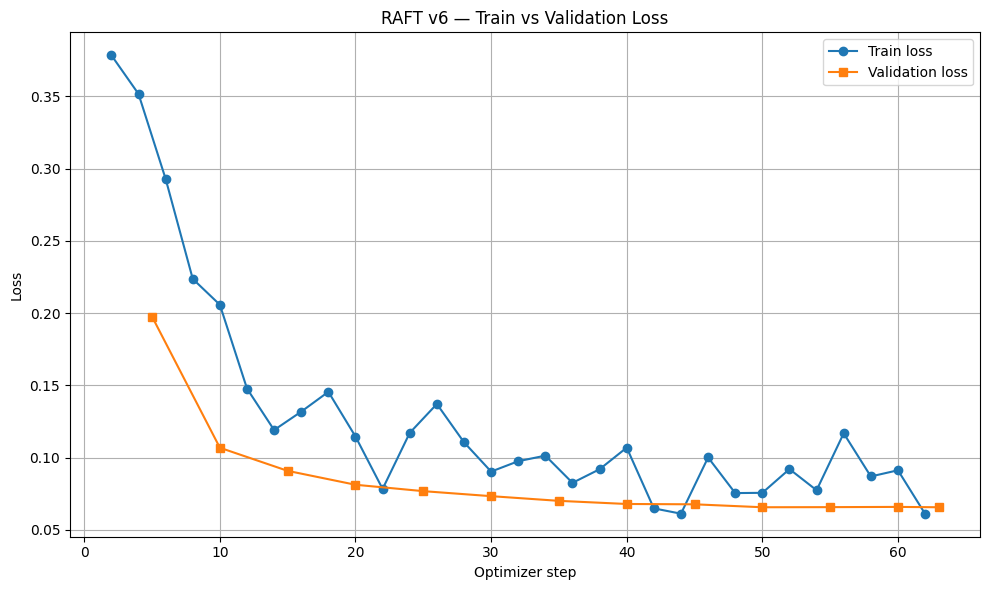

Plot disimpan: ../model/runs/raft_v6_none5_partial2_seed3407_20260717_002824/train_validation_loss.png


In [15]:
import matplotlib.pyplot as plt

log_history = trainer.state.log_history

train_logs = [
    item for item in log_history
    if "loss" in item and "eval_loss" not in item
]
eval_logs = [
    item for item in log_history
    if "eval_loss" in item
]

plt.figure(figsize=(10, 6))

if train_logs:
    plt.plot(
        [item["step"] for item in train_logs],
        [item["loss"] for item in train_logs],
        marker="o",
        label="Train loss",
    )

if eval_logs:
    plt.plot(
        [item["step"] for item in eval_logs],
        [item["eval_loss"] for item in eval_logs],
        marker="s",
        label="Validation loss",
    )

plt.xlabel("Optimizer step")
plt.ylabel("Loss")
plt.title("RAFT v6 — Train vs Validation Loss")
plt.grid(True)
plt.legend()
plt.tight_layout()

loss_plot_path = os.path.join(
    OUTPUT_DIR,
    "train_validation_loss.png",
)
plt.savefig(loss_plot_path, dpi=160)
plt.show()

print("Plot disimpan:", loss_plot_path)


## 15. Ringkasan training

In [16]:
summary_rows = []

for item in trainer.state.log_history:
    summary_rows.append(
        {
            "step": item.get("step"),
            "epoch": item.get("epoch"),
            "loss": item.get("loss"),
            "eval_loss": item.get("eval_loss"),
            "learning_rate": item.get("learning_rate"),
        }
    )

metrics_dataframe = pd.DataFrame(summary_rows)
display(metrics_dataframe.tail(30))

print("=" * 72)
print("Best checkpoint :", trainer.state.best_model_checkpoint)
print("Best eval loss  :", trainer.state.best_metric)
print("Global step     :", trainer.state.global_step)
print("=" * 72)

,step,epoch,loss,eval_loss,learning_rate
15,24,1.148148,0.117059,NaN,0.000033
16,25,1.197531,NaN,0.076710,NaN
17,26,1.246914,0.137061,NaN,0.000032
18,28,1.345679,0.110566,NaN,0.000030
19,30,1.444444,0.090251,NaN,0.000028
20,30,1.444444,NaN,0.073242,NaN
21,32,1.543210,0.097451,NaN,0.000027
22,34,1.641975,0.101294,NaN,0.000025
23,35,1.691358,NaN,0.069996,NaN
24,36,1.740741,0.082455,NaN,0.000023


Best checkpoint : ../model/runs/raft_v6_none5_partial2_seed3407_20260717_002824/checkpoint-63
Best eval loss  : 0.06556213647127151
Global step     : 63


## 16. Inference dengan template yang sama

Evaluasi generation dilakukan terhadap model pada checkpoint terbaik yang otomatis dimuat kembali oleh Trainer.

In [17]:
FastLanguageModel.for_inference(model)


def generate_answer(
    instruction,
    documents,
    max_new_tokens=512,
    inference_model=None,
    inference_tokenizer=None,
):
    active_model = (
        inference_model
        if inference_model is not None
        else model
    )
    active_tokenizer = (
        inference_tokenizer
        if inference_tokenizer is not None
        else tokenizer
    )

    messages = [
        {"role": "system", "content": SYSTEM_PROMPT},
        {
            "role": "user",
            "content": (
                f"Pertanyaan:\n{instruction.strip()}\n\n"
                f"Dokumen Referensi:\n"
                f"{format_documents(documents)}"
            ),
        },
    ]

    input_ids = active_tokenizer.apply_chat_template(
        messages,
        tokenize=True,
        add_generation_prompt=True,
        return_tensors="pt",
    ).to(active_model.device)

    attention_mask = torch.ones_like(input_ids)

    generation_config = GenerationConfig(
        max_new_tokens=max_new_tokens,
        do_sample=False,
        use_cache=True,
        eos_token_id=active_tokenizer.eos_token_id,
        pad_token_id=active_tokenizer.pad_token_id,
    )

    with torch.inference_mode():
        output_ids = active_model.generate(
            input_ids=input_ids,
            attention_mask=attention_mask,
            generation_config=generation_config,
        )

    generated_ids = output_ids[0, input_ids.shape[1]:]

    return active_tokenizer.decode(
        generated_ids,
        skip_special_tokens=True,
    ).strip()


## 17. Parser dan metrik generation

In [18]:
ID_LINE_PATTERNS = {
    "selected": re.compile(
        r"^KONTEKS_DIPILIH\s*:\s*(.*)$",
        re.IGNORECASE | re.MULTILINE,
    ),
    "rejected": re.compile(
        r"^KONTEKS_DITOLAK\s*:\s*(.*)$",
        re.IGNORECASE | re.MULTILINE,
    ),
}

REASON_LINE_PATTERN = re.compile(
    r"^-\s*Dokumen\s+(\d+)\s*:\s*"
    r"(DIPILIH|DITOLAK)\s*[—-]\s*(.+)$",
    re.IGNORECASE | re.MULTILINE,
)

NO_ANSWER_PATTERNS = [
    "informasi tidak ditemukan",
    "tidak ditemukan pada dokumen",
    "dokumen yang diberikan tidak memuat",
    "tidak tersedia dalam dokumen",
]


def parse_document_id_line(text, field):
    match = ID_LINE_PATTERNS[field].search(text)
    if not match:
        return None

    value = match.group(1).strip()
    normalized_value = value.lower()

    if normalized_value in {
        "",
        "-",
        "[]",
        "tidak ada",
        "none",
        "null",
    }:
        return []

    return sorted({
        int(number)
        for number in re.findall(r"\d+", value)
    })


def parse_document_reasons(text):
    reasons = {}
    duplicate_ids = set()

    for match in REASON_LINE_PATTERN.finditer(text):
        document_id = int(match.group(1))
        status = match.group(2).upper()
        reason = match.group(3).strip()

        if document_id in reasons:
            duplicate_ids.add(document_id)

        reasons[document_id] = {
            "status": status,
            "reason": reason,
        }

    return reasons, duplicate_ids


def parse_final_answer(text):
    match = re.search(
        r"^JAWABAN\s*:\s*(.*)$",
        text,
        re.IGNORECASE | re.MULTILINE | re.DOTALL,
    )
    return match.group(1).strip() if match else ""


def is_no_answer_text(text):
    normalized = re.sub(
        r"\s+",
        " ",
        str(text).lower(),
    ).strip()
    return any(
        pattern in normalized
        for pattern in NO_ANSWER_PATTERNS
    )


def safe_divide(numerator, denominator):
    return numerator / denominator if denominator else 0.0


def set_precision_recall_f1(predicted, expected):
    predicted = set(predicted)
    expected = set(expected)

    # Prediksi kosong dan oracle kosong adalah keputusan sempurna.
    if not predicted and not expected:
        return 1.0, 1.0, 1.0

    true_positive = len(predicted & expected)
    precision = safe_divide(true_positive, len(predicted))
    recall = safe_divide(true_positive, len(expected))
    f1 = safe_divide(
        2 * precision * recall,
        precision + recall,
    )
    return precision, recall, f1


def answer_token_f1(predicted, expected):
    predicted_tokens = re.findall(
        r"[a-z0-9]+",
        predicted.lower(),
    )
    expected_tokens = re.findall(
        r"[a-z0-9]+",
        expected.lower(),
    )

    if not predicted_tokens and not expected_tokens:
        return 1.0
    if not predicted_tokens or not expected_tokens:
        return 0.0

    predicted_counts = Counter(predicted_tokens)
    expected_counts = Counter(expected_tokens)

    overlap = sum(
        min(predicted_counts[token], expected_counts[token])
        for token in predicted_counts
    )

    precision = safe_divide(overlap, len(predicted_tokens))
    recall = safe_divide(overlap, len(expected_tokens))

    return safe_divide(
        2 * precision * recall,
        precision + recall,
    )


## 18. Evaluasi generation pada validation set

In [19]:
def summarize_generation_metrics(predictions):
    metric_columns = [
        "selected_exact",
        "rejected_exact",
        "partition_exact",
        "context_precision",
        "context_recall",
        "context_f1",
        "answerability_correct",
        "strict_format_compliant",
        "reason_status_consistent",
        "abstention_consistent",
        "answer_token_f1",
        "distractor_false_positive_rate",
        "oracle_miss_rate",
    ]

    metrics = {
        column: float(predictions[column].mean())
        for column in metric_columns
    }

    metrics["invalid_id_total"] = int(
        predictions["invalid_id_count"].sum()
    )
    metrics["num_examples"] = len(predictions)

    none_rows = predictions[
        predictions["answerability"] == "none"
    ]
    answerable_rows = predictions[
        predictions["answerability"].isin(["full", "partial"])
    ]

    metrics["none_count"] = len(none_rows)
    metrics["answerable_count"] = len(answerable_rows)

    metrics["false_acceptance_rate_none"] = (
        float((~none_rows["answerability_correct"]).mean())
        if len(none_rows)
        else None
    )
    metrics["false_rejection_rate_answerable"] = (
        float((~answerable_rows["answerability_correct"]).mean())
        if len(answerable_rows)
        else None
    )

    per_class = {}
    for answerability, group in predictions.groupby(
        "answerability",
        dropna=False,
    ):
        per_class[str(answerability)] = {
            "num_examples": int(len(group)),
            "selected_exact": float(
                group["selected_exact"].mean()
            ),
            "answerability_correct": float(
                group["answerability_correct"].mean()
            ),
            "strict_format_compliant": float(
                group["strict_format_compliant"].mean()
            ),
            "answer_token_f1": float(
                group["answer_token_f1"].mean()
            ),
        }

    metrics["per_answerability"] = per_class
    return metrics


def evaluate_generation(
    dataset,
    split_name,
    max_examples=None,
    inference_model=None,
    inference_tokenizer=None,
):
    records = (
        list(dataset)
        if max_examples is None
        else list(dataset)[:max_examples]
    )

    rows = []

    for index, record in enumerate(records, start=1):
        raw_output = generate_answer(
            instruction=record["instruction"],
            documents=record["documents"],
            inference_model=inference_model,
            inference_tokenizer=inference_tokenizer,
        )

        predicted_selected = parse_document_id_line(
            raw_output,
            "selected",
        )
        predicted_rejected = parse_document_id_line(
            raw_output,
            "rejected",
        )
        predicted_reasons, duplicate_reason_ids = (
            parse_document_reasons(raw_output)
        )
        predicted_answer = parse_final_answer(raw_output)

        expected_selected = sorted(
            record["selected_doc_ids"]
        )
        expected_rejected = sorted(
            record["rejected_doc_ids"]
        )

        document_count = len(record["documents"])
        valid_ids = set(range(1, document_count + 1))

        parsed_context = (
            predicted_selected is not None
            and predicted_rejected is not None
        )

        if parsed_context:
            predicted_partition = (
                set(predicted_selected)
                | set(predicted_rejected)
            )
            invalid_ids = predicted_partition - valid_ids
            overlap_ids = (
                set(predicted_selected)
                & set(predicted_rejected)
            )
            partition_complete = (
                predicted_partition == valid_ids
                and not overlap_ids
                and not invalid_ids
            )
        else:
            invalid_ids = set()
            overlap_ids = set()
            partition_complete = False

        predicted_selected_for_metric = (
            predicted_selected
            if predicted_selected is not None
            else []
        )

        precision, recall, context_f1 = (
            set_precision_recall_f1(
                predicted_selected_for_metric,
                expected_selected,
            )
        )

        reason_ids = set(predicted_reasons)
        reason_ids_complete = (
            reason_ids == valid_ids
            and not duplicate_reason_ids
        )

        reason_status_consistent = False
        if parsed_context and reason_ids_complete:
            selected_set = set(predicted_selected)
            rejected_set = set(predicted_rejected)
            reason_status_consistent = all(
                (
                    predicted_reasons[document_id]["status"]
                    == (
                        "DIPILIH"
                        if document_id in selected_set
                        else "DITOLAK"
                    )
                )
                for document_id in valid_ids
            ) and selected_set | rejected_set == valid_ids

        answer_present = bool(predicted_answer.strip())
        expected_answerability = record["answerability"]
        predicted_refusal = is_no_answer_text(
            predicted_answer
        )

        if expected_answerability == "none":
            answerability_correct = (
                predicted_selected_for_metric == []
                and predicted_refusal
            )
        else:
            answerability_correct = (
                bool(predicted_selected_for_metric)
                and not predicted_refusal
                and answer_present
            )

        abstention_consistent = (
            (
                predicted_selected_for_metric == []
                and predicted_refusal
            )
            or (
                bool(predicted_selected_for_metric)
                and not predicted_refusal
            )
        )

        selected_set = set(predicted_selected_for_metric)
        expected_selected_set = set(expected_selected)
        expected_rejected_set = set(expected_rejected)

        distractor_false_positive_rate = safe_divide(
            len(selected_set & expected_rejected_set),
            len(expected_rejected_set),
        )
        oracle_miss_rate = safe_divide(
            len(expected_selected_set - selected_set),
            len(expected_selected_set),
        )

        strict_format_compliant = (
            parsed_context
            and partition_complete
            and reason_ids_complete
            and reason_status_consistent
            and answer_present
        )

        rows.append(
            {
                "record_id": record["record_id"],
                "answerability": expected_answerability,
                "selected_exact": (
                    predicted_selected == expected_selected
                ),
                "rejected_exact": (
                    predicted_rejected == expected_rejected
                ),
                "partition_exact": (
                    predicted_selected == expected_selected
                    and predicted_rejected == expected_rejected
                ),
                "context_precision": precision,
                "context_recall": recall,
                "context_f1": context_f1,
                "answerability_correct": answerability_correct,
                "strict_format_compliant": strict_format_compliant,
                "reason_status_consistent": reason_status_consistent,
                "abstention_consistent": abstention_consistent,
                "invalid_id_count": len(invalid_ids),
                "answer_token_f1": answer_token_f1(
                    predicted_answer,
                    record["completion"],
                ),
                "distractor_false_positive_rate": (
                    distractor_false_positive_rate
                ),
                "oracle_miss_rate": oracle_miss_rate,
                "expected_selected": expected_selected,
                "predicted_selected": predicted_selected,
                "expected_rejected": expected_rejected,
                "predicted_rejected": predicted_rejected,
                "expected_answer": record["completion"],
                "predicted_answer": predicted_answer,
                "raw_output": raw_output,
            }
        )

        print(
            f"[{index:02d}/{len(records):02d}] "
            f"{record['record_id']} | "
            f"selected_exact={rows[-1]['selected_exact']} | "
            f"answerability={rows[-1]['answerability_correct']} | "
            f"answer_f1={rows[-1]['answer_token_f1']:.3f}"
        )

    predictions = pd.DataFrame(rows)
    metrics = summarize_generation_metrics(predictions)

    predictions_path = os.path.join(
        OUTPUT_DIR,
        f"{split_name}_generation_predictions.csv",
    )
    metrics_path = os.path.join(
        OUTPUT_DIR,
        f"{split_name}_generation_metrics.json",
    )

    predictions.to_csv(
        predictions_path,
        index=False,
        encoding="utf-8-sig",
    )
    with open(metrics_path, "w", encoding="utf-8") as file:
        json.dump(
            metrics,
            file,
            indent=2,
            ensure_ascii=False,
        )

    return metrics, predictions


validation_metrics, validation_predictions = (
    evaluate_generation(
        validation_raw,
        split_name="validation_adapter",
    )
)

print("\nVALIDATION GENERATION METRICS")
print(
    json.dumps(
        validation_metrics,
        indent=2,
        ensure_ascii=False,
    )
)


Passing `generation_config` together with generation-related arguments=({'pad_token_id', 'cache_implementation'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
Both `max_new_tokens` (=512) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
/workspace/.venv/lib/python3.10/site-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/workspace/.venv/lib/python3.10/site-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: Th

[01/34] raft-v5-0082 | selected_exact=True | answerability=True | answer_f1=0.967


Both `max_new_tokens` (=512) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


[02/34] raft-v5-0085 | selected_exact=True | answerability=True | answer_f1=0.865


Both `max_new_tokens` (=512) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


...

[31/34] raft-v5-0350 | selected_exact=True | answerability=True | answer_f1=0.475


Both `max_new_tokens` (=512) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


[32/34] raft-v5-0360 | selected_exact=True | answerability=True | answer_f1=1.000


Both `max_new_tokens` (=512) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


[33/34] raft-v5-0367 | selected_exact=True | answerability=True | answer_f1=0.750
[34/34] raft-v5-0377 | selected_exact=True | answerability=True | answer_f1=1.000

VALIDATION GENERATION METRICS
{
  "selected_exact": 0.7941176470588235,
  "rejected_exact": 0.7941176470588235,
  "partition_exact": 0.7941176470588235,
  "context_precision": 0.9117647058823529,
  "context_recall": 0.9019607843137254,
  "context_f1": 0.896078431372549,
  "answerability_correct": 0.9411764705882353,
  "strict_format_compliant": 1.0,
  "reason_status_consistent": 1.0,
  "abstention_consistent": 1.0,
  "answer_token_f1": 0.7831324179851739,
  "distractor_false_positive_rate": 0.027941176470588233,
  "oracle_miss_rate": 0.0392156862745098,
  "invalid_id_total": 0,
  "num_examples": 34,
  "none_count": 4,
  "answerable_count": 30,
  "false_acceptance_rate_none": 0.5,
  "false_rejection_rate_answerable": 0.0,
  "per_answerability": {
    "full": {
      "num_examples": 30,
      "selected_exact": 0.8333333333333

## 19. Evaluasi test set

`RUN_TEST` dibuat `False` secara default.

Test v5 sudah pernah digunakan pada eksperimen sebelumnya. Jangan memakainya
berulang kali untuk memilih hyperparameter. Untuk laporan final, gunakan holdout
baru yang belum pernah dilihat atau bekukan seluruh keputusan sebelum mengaktifkan
sel ini.


In [20]:
if RUN_TEST:
    test_metrics, test_predictions = evaluate_generation(
        test_raw,
        split_name="test_adapter",
    )

    print(
        json.dumps(
            test_metrics,
            indent=2,
            ensure_ascii=False,
        )
    )
else:
    print(
        "Test dilewati. Set RUN_TEST=True hanya setelah seluruh "
        "konfigurasi final dan idealnya gunakan holdout baru."
    )


Test dilewati. Set RUN_TEST=True hanya setelah seluruh konfigurasi final dan idealnya gunakan holdout baru.


## 20. Demo full dan no-answer

In [21]:
def show_demo(record, label):
    output = generate_answer(
        instruction=record["instruction"],
        documents=record["documents"],
    )

    print("=" * 80)
    print(label)
    print("PERTANYAAN")
    print(record["instruction"])
    print("\nANSWERABILITY")
    print(record["answerability"])
    print("\nEXPECTED SELECTED")
    print(record["selected_doc_ids"])
    print("\nMODEL OUTPUT")
    print(output)


full_demo = next(
    record
    for record in validation_raw
    if record["answerability"] == "full"
)
show_demo(full_demo, "DEMO FULL")

none_candidates = [
    record
    for record in validation_raw
    if record["answerability"] == "none"
]
if none_candidates:
    show_demo(none_candidates[0], "DEMO NONE")
else:
    print("Validation tidak mempunyai contoh none.")


Both `max_new_tokens` (=512) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
/workspace/.venv/lib/python3.10/site-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/workspace/.venv/lib/python3.10/site-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
Both `max_ne

DEMO FULL
PERTANYAAN
Apa yang dimaksud dengan "peraturan desa" menurut Peraturan Desa Biru No. 07 Tahun 2015, Pasal 1?

ANSWERABILITY
full

EXPECTED SELECTED
[4]

MODEL OUTPUT
KONTEKS_DIPILIH: 4
KONTEKS_DITOLAK: 1, 2, 3, 5

ALASAN_DOKUMEN:
- Dokumen 1: DITOLAK — berasal dari peraturan yang berbeda
- Dokumen 2: DITOLAK — berasal dari peraturan yang berbeda
- Dokumen 3: DITOLAK — berasal dari peraturan yang berbeda
- Dokumen 4: DIPILIH — menjawab pertanyaan secara langsung
- Dokumen 5: DITOLAK — berasal dari peraturan yang berbeda

JAWABAN:
Peraturan desa menurut Peraturan Desa Biru No. 07 Tahun 2015, Pasal 1 adalah kebijakan penyelenggaraan pemerintahan desa yang ditetapkan oleh kepala desa setelah mendapat persetujuan dari badan permusyawaratan desa.
DEMO NONE
PERTANYAAN
Apa konsekuensi jika mmd sebagaimana dimaksud pada ayat 1 tidak dihadiri oleh seluruh perwakilan masyarakat desa Biru dan petugas kesehatan, minimal bidan desa, menurut Peraturan Desa Biru No. 07 Tahun 2015?

ANSWERABI

## 21. Menyimpan adapter dan merged model

In [24]:
def sha256_file(path):
    digest = hashlib.sha256()
    with open(path, "rb") as file:
        for chunk in iter(lambda: file.read(1024 * 1024), b""):
            digest.update(chunk)
    return digest.hexdigest()


Path(ADAPTER_DIR).mkdir(parents=True, exist_ok=False)
Path(MERGED_DIR).mkdir(parents=True, exist_ok=False)

model.save_pretrained(ADAPTER_DIR)
tokenizer.save_pretrained(ADAPTER_DIR)

print("LoRA adapter disimpan ke:", ADAPTER_DIR)

model.save_pretrained_merged(
    MERGED_DIR,
    tokenizer,
    save_method="merged_16bit",
)

print("Merged 16-bit model disimpan ke:", MERGED_DIR)

run_config = {
    "run_id": RUN_ID,
    "created_at": datetime.now().isoformat(),
    "model_name": MODEL_NAME,
    "max_seq_length": MAX_SEQ_LENGTH,
    "load_in_4bit": LOAD_IN_4BIT,
    "seed": SEED,
    "answerability_oversampling": {
        "enabled": ENABLE_ANSWERABILITY_OVERSAMPLING,
        "none_repeat": NONE_REPEAT,
        "partial_repeat": PARTIAL_REPEAT,
    },
    "dataset_paths": {
        "train": TRAIN_DATASET_PATH,
        "validation": VALIDATION_DATASET_PATH,
        "test": TEST_DATASET_PATH,
    },
    "dataset_sha256": {
        "train": sha256_file(TRAIN_DATASET_PATH),
        "validation": sha256_file(VALIDATION_DATASET_PATH),
        "test": sha256_file(TEST_DATASET_PATH),
    },
    "library_versions": {
        "python": platform.python_version(),
        "torch": torch.__version__,
        "transformers": transformers.__version__,
        "trl": trl.__version__,
        "unsloth": importlib.metadata.version("unsloth"),
        "datasets": importlib.metadata.version("datasets"),
        "peft": importlib.metadata.version("peft"),
    },
    "best_checkpoint": trainer.state.best_model_checkpoint,
    "best_eval_loss": trainer.state.best_metric,
    "global_step": trainer.state.global_step,
    "sft_config": config_kwargs,
    "generation_config": {
        "max_new_tokens": 512,
        "do_sample": False,
    },
    "validation_metrics": validation_metrics,
}

if RUN_TEST:
    run_config["test_metrics"] = test_metrics

with open(
    os.path.join(OUTPUT_DIR, "run_config.json"),
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        run_config,
        file,
        ensure_ascii=False,
        indent=2,
        default=str,
    )

print("Konfigurasi eksperimen disimpan.")


LoRA adapter disimpan ke: /workspace/model/raft_v6_none5_partial2_seed3407_20260717_002824_adapter
Detected local model directory: /workspace/model/Meta-Llama-3.1-8B-Instruct


Unsloth: Restored added_tokens_decoder metadata in /workspace/model/raft_v6_none5_partial2_seed3407_20260717_002824_merged/tokenizer_config.json.


Found HuggingFace hub cache directory: /home/kel07/.cache/huggingface/hub


Unsloth: Preparing safetensor model files:  25%|██▌       | 1/4 [00:01<00:03,  1.03s/it]

Copied model-00004-of-00004.safetensors from local model directory


...

Copied model-00002-of-00004.safetensors from local model directory


Unsloth: Preparing safetensor model files: 100%|██████████| 4/4 [00:14<00:00,  3.65s/it]


Copied model-00001-of-00004.safetensors from local model directory


Unsloth: Merging weights into 16bit: 100%|██████████| 4/4 [00:47<00:00, 11.93s/it]


Unsloth: Merge process complete. Saved to `/workspace/model/raft_v6_none5_partial2_seed3407_20260717_002824_merged`
Merged 16-bit model disimpan ke: /workspace/model/raft_v6_none5_partial2_seed3407_20260717_002824_merged
Konfigurasi eksperimen disimpan.


## 22. Verifikasi merged model setelah reload

Merged model harus diuji dalam keadaan dimuat ulang. Ini mendeteksi masalah merge,
tokenizer, atau konfigurasi generation yang tidak terlihat saat adapter masih aktif.


In [25]:
if VERIFY_MERGED_MODEL:
    # Simpan data yang dibutuhkan sebelum model/trainer dilepas.
    adapter_validation_metrics = dict(validation_metrics)

    del trainer
    del model
    gc.collect()
    torch.cuda.empty_cache()

    merged_model, merged_tokenizer = (
        FastLanguageModel.from_pretrained(
            model_name=MERGED_DIR,
            max_seq_length=MAX_SEQ_LENGTH,
            dtype=DTYPE,
            load_in_4bit=False,
        )
    )
    FastLanguageModel.for_inference(merged_model)

    if merged_tokenizer.pad_token_id is None:
        merged_tokenizer.pad_token = merged_tokenizer.eos_token
    merged_tokenizer.padding_side = "right"

    merged_validation_metrics, merged_validation_predictions = (
        evaluate_generation(
            validation_raw,
            split_name="validation_merged",
            inference_model=merged_model,
            inference_tokenizer=merged_tokenizer,
        )
    )

    comparison = {
        "adapter_selected_exact": (
            adapter_validation_metrics["selected_exact"]
        ),
        "merged_selected_exact": (
            merged_validation_metrics["selected_exact"]
        ),
        "adapter_answer_token_f1": (
            adapter_validation_metrics["answer_token_f1"]
        ),
        "merged_answer_token_f1": (
            merged_validation_metrics["answer_token_f1"]
        ),
    }

    comparison_path = os.path.join(
        OUTPUT_DIR,
        "adapter_vs_merged_metrics.json",
    )
    with open(
        comparison_path,
        "w",
        encoding="utf-8",
    ) as file:
        json.dump(
            comparison,
            file,
            ensure_ascii=False,
            indent=2,
        )

    print(json.dumps(comparison, indent=2))
    print("Perbandingan disimpan:", comparison_path)
else:
    print("Verifikasi merged model dilewati.")


==((====))==  Unsloth 2026.6.9: Fast Llama patching. Transformers: 5.5.0.
   \\   /|    NVIDIA B200. Num GPUs = 1. Max memory: 178.361 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.11.0+cu128. CUDA: 10.0. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = TRUE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights: 100%|██████████| 291/291 [00:04<00:00, 65.07it/s]
The tokenizer you are loading from '/workspace/model/raft_v6_none5_partial2_seed3407_20260717_002824_merged' with an incorrect regex pattern: https://huggingface.co/mistralai/Mistral-Small-3.1-24B-Instruct-2503/discussions/84#69121093e8b480e709447d5e. This will lead to incorrect tokenization. You should set the `fix_mistral_regex=True` flag when loading this tokenizer to fix this issue.
The tokenizer you are loading from '/workspace/model/raft_v6_none5_partial2_seed3407_20260717_002824_merged' with an incorrect regex pattern: https://huggingface.co/mistralai/Mistral-Small-3.1-24B-Instruct-2503/discussions/84#69121093e8b480e709447d5e. This will lead to incorrect tokenization. You should set the `fix_mistral_regex=True` flag when loading this tokenizer to fix this issue.
Unsloth: Will load /workspace/model/raft_v6_none5_partial2_seed3407_20260717_002824_merged as a legacy tokenizer.
Both `max_new_tokens` (=512) and `max_l

[01/34] raft-v5-0082 | selected_exact=True | answerability=True | answer_f1=0.967


Both `max_new_tokens` (=512) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


[02/34] raft-v5-0085 | selected_exact=True | answerability=True | answer_f1=0.865


...

[31/34] raft-v5-0350 | selected_exact=True | answerability=True | answer_f1=0.754


Both `max_new_tokens` (=512) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


[32/34] raft-v5-0360 | selected_exact=True | answerability=True | answer_f1=1.000


Both `max_new_tokens` (=512) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


[33/34] raft-v5-0367 | selected_exact=True | answerability=True | answer_f1=0.750
[34/34] raft-v5-0377 | selected_exact=True | answerability=True | answer_f1=1.000
{
  "adapter_selected_exact": 0.7941176470588235,
  "merged_selected_exact": 0.7941176470588235,
  "adapter_answer_token_f1": 0.7831324179851739,
  "merged_answer_token_f1": 0.78335987963538
}
Perbandingan disimpan: ../model/runs/raft_v6_none5_partial2_seed3407_20260717_002824/adapter_vs_merged_metrics.json


## 23. Membersihkan VRAM (opsional)

In [1]:
# Jalankan hanya setelah training, evaluasi, dan penyimpanan selesai.

del trainer
del model
gc.collect()
torch.cuda.empty_cache()
print("VRAM dibersihkan.")

NameError: name 'trainer' is not defined